In [13]:
import ee
import time
import json
import geemap.foliumap as geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

ee.Authenticate()
ee.Initialize(project="vital-wavelet-217112")
dataset_source = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")
crs_str = dataset_source.first().projection().crs().getInfo()
base_proj = dataset_source.first().projection()

Enter verification code:  4/1ATsMZqBr9p1zQre8cijTUsOkfZ_HO-hMNBftpRXl2XeelAQUT6bpLG4wRJs



Successfully saved authorization token.


In [14]:
tile = gpd.read_file("./dataset/tile_C51L41_WGS84.gpkg")
if tile.crs != "EPSG:4326":
    tile = tile.to_crs(epsg=4326)
roi_geojson = json.loads(tile.to_json())
ee_fc_roi = ee.FeatureCollection(roi_geojson)
ee_roi = ee.FeatureCollection(json.loads(tile.to_json()))
tile

,id,i,col,row,area,area_rel,geometry
0,C51L41,4.0,51.0,41.0,7.650154e+08,98.996435,"POLYGON ((-61 -8.25, -61.25 -8.25, -61.25 -8, ..."


In [7]:
year = 2024
label = "DESMATAMENTO_CR"
label_column = "CLASS"

samples = gpd.read_file("./dataset/Deter20_24_C51L41.gpkg")
samples = samples[samples["DATE"].dt.year == year]
samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
geojson = json.loads(samples.drop(columns=["DATE"]).to_json())
ee_fc_samples = ee.FeatureCollection(geojson)
ee_samples = ee.FeatureCollection(geojson)
samples.head()

,id,i,CLASS,PATH_ROW,DATE,SENSOR,SATELLITE,YEAR,area_rel,AREA_FDAS,geometry
87,C51L41,4.0,DESMATAMENTO_CR,038016,2024-10-13,WFI,AMAZONIA-1,2024.0,99.022909,341764.560080,"MULTIPOLYGON (((-61.20656 -8.20703, -61.20364 ..."
100,C51L41,4.0,DESMATAMENTO_CR,038016,2024-05-31,WFI,AMAZONIA-1,2024.0,99.022909,106798.526831,"MULTIPOLYGON (((-61.22561 -8.22452, -61.22561 ..."
101,C51L41,4.0,DESMATAMENTO_CR,038016,2024-05-31,WFI,AMAZONIA-1,2024.0,99.022909,278.722474,"MULTIPOLYGON (((-61.2161 -8.22847, -61.216 -8...."
102,C51L41,4.0,DESMATAMENTO_CR,038016,2024-05-31,WFI,AMAZONIA-1,2024.0,99.022909,250891.241569,"MULTIPOLYGON (((-61.20831 -8.19, -61.20839 -8...."
103,C51L41,4.0,DESMATAMENTO_CR,038016,2024-05-31,WFI,AMAZONIA-1,2024.0,99.022909,6126.067154,"MULTIPOLYGON (((-61.19409 -8.18874, -61.19155 ..."


In [8]:
year = 2024
label = "Deter_Deg_CsG"
label_column = "class_multisource"

samples = gpd.read_file("./dataset/Aut_C51L41_preclass.gpkg")
samples = samples[samples["date_multisource"].dt.year == year]
samples = samples[samples[label_column] == label]
if samples.crs != "EPSG:4326":
    samples = samples.to_crs(epsg=4326)
geojson = json.loads(samples.drop(columns=["date", "date_multisource"]).to_json())
ee_fc_samples = ee.FeatureCollection(geojson)
ee_samples = ee.FeatureCollection(geojson)
samples.head()

,doy_2020,date,idx,class_multisource,date_multisource,geometry
73,7,2020-01-07,74,Deter_Deg_CsG,2024-10-07,"POLYGON ((-61.1488 -8.0953, -61.1489 -8.0953, ..."
6720,212,2020-07-30,6721,Deter_Deg_CsG,2024-01-02,"POLYGON ((-61.1597 -8.108, -61.1596 -8.108, -6..."
7628,217,2020-08-04,7629,Deter_Deg_CsG,2024-01-02,"POLYGON ((-61.1595 -8.108, -61.1595 -8.1081, -..."
7629,217,2020-08-04,7630,Deter_Deg_CsG,2024-01-02,"POLYGON ((-61.1597 -8.1078, -61.1597 -8.1081, ..."
10816,227,2020-08-14,10817,Deter_Deg_CsG,2024-01-02,"POLYGON ((-61.1596 -8.1079, -61.1596 -8.108, -..."


In [15]:
# Criar o mapa interativo centrado na nossa ROI
Map = geemap.Map(ee_initialize=False)
Map.centerObject(ee_fc_roi, 12)

ee_fc_roi_ = ee_fc_roi.style(
    color='FF0000',      # Cor da borda (Vermelho)
    width=2,             # Espessura da linha
    fillColor='00000000' # Transparente (8 dígitos hex: RRGGBBAA)
)
# Adicionar as camadas ao mapa
Map.addLayer(ee_fc_roi_, {}, 'Region of Interest')

ee_fc_samples_ = ee_fc_samples.style(
    color='grey',      # Cor da borda (Vermelho)
    width=2,             # Espessura da linha
    fillColor='00000000' # Transparente (8 dígitos hex: RRGGBBAA)
)
# Adicionar as camadas ao mapa
Map.addLayer(ee_fc_samples_, { }, f'{year} {label} Distúrbios')

# Mostrar o mapa na tela do Colab
Map

In [16]:
def calculate_pca_rgb(image, roi, scale=10, crs_str=None, use_percentiles=True):
    band_names = image.bandNames()
    
    # 1. Compute mean for each band and center the image
    mean_dict = image.reduceRegion(
        reducer=ee.Reducer.mean(),
        crs=crs_str,
        geometry=roi,
        scale=scale,
        maxPixels=1e13,
        bestEffort=True,
        tileScale=8
    )
    mean_image = image.subtract(mean_dict.toImage(band_names))
    
    # 2. Convert centered bands to a 1D array per pixel: shape [64]
    array_image = mean_image.toArray()
    
    # 3. Compute Covariance Matrix
    covar_dict = array_image.reduceRegion(
        reducer=ee.Reducer.centeredCovariance(),
        crs=crs_str,
        geometry=roi,
        scale=scale,
        maxPixels=1e13,
        bestEffort=True,
        tileScale=8
    )
    covar_array = ee.Array(covar_dict.get('array'))
    
    # 4. Perform Eigen decomposition
    eigen_dict = covar_array.eigen()
    eigen_vectors = eigen_dict.slice(1, 1)  # shape (64, 64)
    
    # 5. Project centered pixels onto eigenvectors
    array_image_2d = array_image.toArray(1)
    components = ee.Image(eigen_vectors).matrixMultiply(array_image_2d)
    
    # 6. Extract top 3 Principal Components
    pc1 = components.arrayGet([0, 0]).rename('PC1')
    pc2 = components.arrayGet([1, 0]).rename('PC2')
    pc3 = components.arrayGet([2, 0]).rename('PC3')
    pca_raw = ee.Image.cat([pc1, pc2, pc3])
    
    # 7. Min-Max Normalization to [0, 1]
    if use_percentiles:
        # Robust 2%-98% stretch to prevent outlier distortion
        reducer = ee.Reducer.percentile([2, 98])
        min_suffix, max_suffix = '_p2', '_p98'
    else:
        # Absolute min-max
        reducer = ee.Reducer.minMax()
        min_suffix, max_suffix = '_min', '_max'
        
    stats = pca_raw.reduceRegion(
        reducer=reducer,
        crs=crs_str,
        geometry=roi,
        scale=scale,
        maxPixels=1e13,
        bestEffort=True,
        tileScale=8
    )
    
    min_img = ee.Image.constant([
        stats.get(f'PC1{min_suffix}'),
        stats.get(f'PC2{min_suffix}'),
        stats.get(f'PC3{min_suffix}')
    ])
    
    max_img = ee.Image.constant([
        stats.get(f'PC1{max_suffix}'),
        stats.get(f'PC2{max_suffix}'),
        stats.get(f'PC3{max_suffix}')
    ])
    
    # (X - Min) / (Max - Min), clamped to [0, 1]
    pca_scaled = (
        pca_raw.subtract(min_img)
        .divide(max_img.subtract(min_img))
        .clamp(0.0, 1.0)
        .rename(['R', 'G', 'B'])
    )
    
    return pca_scaled
    
dataset = dataset_source.filterDate(f'{year}-01-01', f'{year}-12-31').filterBounds(ee_roi).mosaic().clip(ee_roi)

pca_image = calculate_pca_rgb(dataset, ee_roi, scale=10)

In [18]:
Map = geemap.Map(ee_initialize=False)
Map.centerObject(ee_roi, 12)

vis = {
    "bands": ["A00", "A16", "A09"],
    "min": -0.2,
    "max": 0.2,
}
Map.addLayer(dataset, vis, "AlphaEarth")

pca_vis = {
    'bands': ['R', 'G', 'B'],
    'min': 0,
    'max': 1
}
Map.addLayer(pca_image, pca_vis, 'AlphaEarth Embeddings PCA (RGB)')

Map.addLayer(ee_fc_samples_, { }, f'{year} Distúrbios')

Map

In [49]:
output_dir = "./dataset/rasters"
os.makedirs(output_dir, exist_ok = True)

task = ee.batch.Export.image.toDrive(
    image=dataset,
    description=f'AlphaEarth_Mosaic_{year}',
    folder='EarthEngine_AlphaEarth',
    fileNamePrefix=f'alphaearth_mosaic_{year}',
    region=ee_roi.geometry(),
    scale=10,
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

task.start()
print(f"Tarefa de exportação iniciada (ID: {task.id}).")

while task.active():
    print(f"Status: {task.status()['state']}...", end="\r")
    time.sleep(10)

print(f"\nFinalizado com status: {task.status()['state']}")

Tarefa de exportação iniciada (ID: IO3EUYFAS23SNUCZLT7CDMFP).
Status: RUNNING...
Finalizado com status: COMPLETED


In [51]:
# # mean dos pixels por polígono
# extracted_fc = dataset.reduceRegions(
#    collection = ee_samples,
#    reducer = ee.Reducer.mean(),
#    scale = 10,
#    tileScale = 4
# )
# por pixel
extracted_pixels_fc = dataset.sampleRegions(
    collection = ee_samples,
    properties = [label_column],
    scale = 10,
    geometries = True,
    tileScale = 4
)

result_gdf = geemap.ee_to_gdf(extracted_pixels_fc)
result_gdf["year"] = year
result_gdf["label"] = result_gdf[label_column]
emb_columns = list([(f"A{i}" if i > 9 else f"A0{i}") for i in range(0, 64)])
samples_embeddings = result_gdf[["geometry", "year", "label"] + emb_columns]
samples_embeddings.to_csv(f"./dataset/samples/samples_{label}_{year}_embeddings_alphaearth_pixel.csv", index=False)
samples_embeddings

,geometry,year,label,A00,A01,A02,A03,A04,A05,A06,...,A54,A55,A56,A57,A58,A59,A60,A61,A62,A63
0,POINT (-61.14882 -8.09521),2024,Deter_Deg_CsG,-0.066990,0.022207,-0.147697,-0.066990,-0.075356,-0.103406,0.008858,...,0.003014,0.113741,0.119093,-0.032541,0.172795,0.007443,0.093564,-0.221453,0.007443,-0.032541
1,POINT (-61.14882 -8.09512),2024,Deter_Deg_CsG,-0.071111,0.027128,-0.147697,-0.071111,-0.079723,-0.103406,0.010396,...,0.007443,0.113741,0.119093,-0.035433,0.172795,0.003937,0.093564,-0.221453,0.010396,-0.029773
2,POINT (-61.15969 -8.10806),2024,Deter_Deg_CsG,-0.035433,-0.041584,-0.071111,-0.124567,-0.079723,0.108512,0.017778,...,0.084214,0.160000,0.130165,-0.013841,0.393695,-0.004983,0.186082,-0.160000,0.199862,-0.221453
3,POINT (-61.1596 -8.10806),2024,Deter_Deg_CsG,-0.044844,-0.062991,-0.119093,-0.103406,-0.088827,0.032541,0.003937,...,0.055363,0.179377,0.113741,-0.003937,0.355309,0.004983,0.172795,-0.179377,0.186082,-0.153787
4,POINT (-61.15951 -8.10806),2024,Deter_Deg_CsG,-0.059116,-0.044844,-0.119093,-0.088827,-0.084214,0.013841,-0.007443,...,0.055363,0.199862,0.113741,-0.017778,0.327812,-0.008858,0.166336,-0.186082,0.172795,-0.153787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4026,POINT (-61.14396 -8.09926),2024,Deter_Deg_CsG,-0.041584,-0.051734,-0.199862,-0.075356,-0.071111,-0.084214,-0.032541,...,0.010396,0.160000,0.055363,-0.006151,0.192910,-0.035433,0.166336,-0.172795,0.055363,-0.113741
4027,POINT (-61.14828 -8.09458),2024,Deter_Deg_CsG,-0.044844,-0.041584,-0.147697,-0.103406,-0.066990,-0.088827,-0.017778,...,0.017778,0.160000,0.088827,-0.002215,0.206936,0.027128,0.192910,-0.192910,0.071111,-0.071111
4028,POINT (-61.15528 -8.09342),2024,Deter_Deg_CsG,-0.038447,-0.022207,-0.153787,-0.066990,-0.051734,-0.051734,-0.006151,...,0.027128,0.179377,0.088827,0.003014,0.199862,-0.029773,0.124567,-0.172795,0.059116,-0.062991
4029,POINT (-61.14486 -8.09782),2024,Deter_Deg_CsG,-0.079723,-0.010396,-0.172795,-0.059116,-0.071111,-0.088827,-0.003937,...,0.029773,0.160000,0.108512,-0.017778,0.206936,-0.017778,0.135886,-0.206936,0.038447,-0.041584


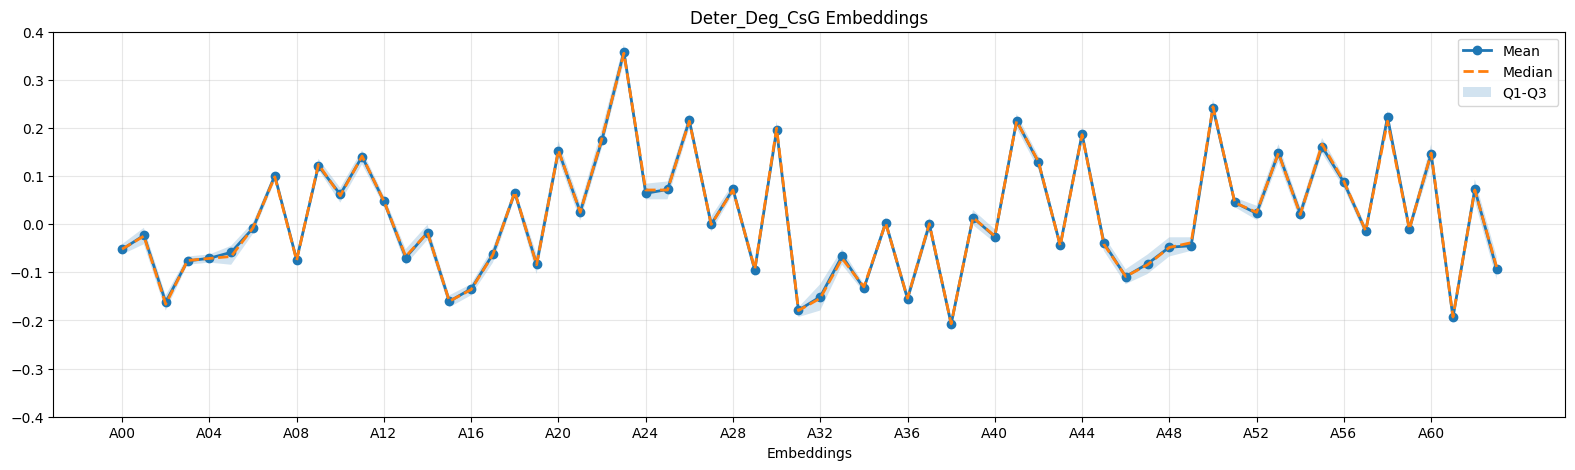

In [52]:
def generatePlotFigPatterns(data, label, smoothing = False, window_length = 7, polyorder = 2):
    only_values = data
    # Statistics
    mean_values = only_values.mean(axis=0)
    median_values = only_values.median(axis=0)
    q1 = only_values.quantile(0.25, axis=0)
    q3 = only_values.quantile(0.75, axis=0)

    if smoothing:
        mean_values = savgol_filter(mean_values, window_length=window_length, polyorder=polyorder)
        median_values = savgol_filter(median_values, window_length=window_length, polyorder=polyorder)
        q1 = savgol_filter(q1, window_length=window_length, polyorder=polyorder)
        q3 = savgol_filter(q3, window_length=window_length, polyorder=polyorder)
        
    # Dates
    indexes = data.columns
    # Plot
    fig, ax = plt.subplots(figsize=(18, 5))
    # Mean curve
    ax.plot(
        indexes,
        mean_values,
        marker="o",
        linewidth=2,
        label="Mean"
    )
    # Median curve
    ax.plot(
        indexes,
        median_values,
        linestyle="--",
        linewidth=2,
        label="Median"
    )
    # Quartile interval
    ax.fill_between(
        indexes,
        q1,
        q3,
        alpha=0.2,
        label="Q1-Q3"
    )
    fig.subplots_adjust(left = 0.06)
    ax.set_title(f"{label} Embeddings")
    ax.set_xlabel("Embeddings")
    ax.legend()
    plt.xticks(range(0, 64, 4))
    plt.ylim(-0.4, 0.4)
    plt.grid(True, alpha=0.3)
    plt.show()

labels = set(samples_embeddings["label"])
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    generatePlotFigPatterns(data_[emb_columns], label)

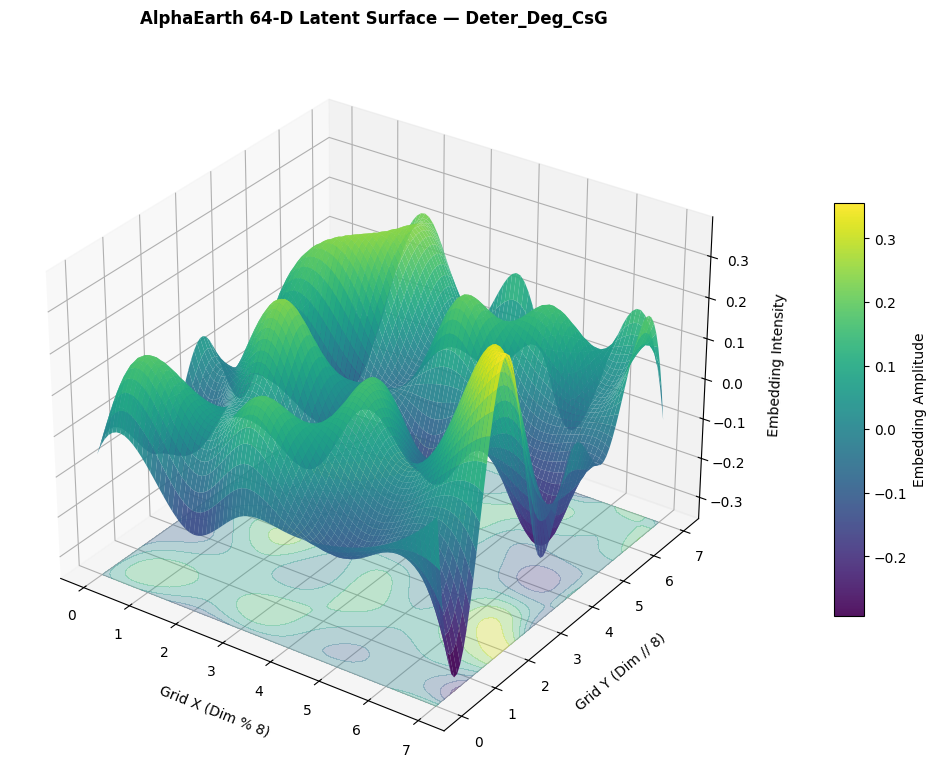

In [53]:
def plot_grid_embedding(embedding, label, values = False):
    embedding = embedding.values
    mean_values = embedding.mean(axis=0)
    Z = mean_values.reshape(8, 8)
    X, Y = np.meshgrid(np.arange(8), np.arange(8))
    
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(
        X, Y, Z,
        cmap='viridis',
        edgecolor='k',
        linewidth=0.5
    )
    if values:
        for i in range(8):
            for j in range(8):
                ax.text(j, i, Z[i, j], f"{Z[i,j]:.3f}", fontsize=7)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_zlabel("Values")
    ax.set_title(f"Grid Embeddings for {label}")
    fig.colorbar(surf, shrink=0.6, label="Embeddings")
    plt.tight_layout()
    plt.show()

def plot_alphaearth_embedding_3d(embedding, label, values=False, smooth_factor=10, cmap='viridis'):
    """
    Plots a 64-dimensional AlphaEarth embedding vector as a smoothed 3D surface.
    
    Parameters:
    - embedding: array-like or DataFrame of shape (64,) or (N, 64)
    - label: str, title/class name for the plot
    - values: bool, whether to display discrete points and numeric labels
    - smooth_factor: int, grid multiplier for interpolation smoothness
    - cmap: str, matplotlib colormap
    """
    # 1. Ensure NumPy array and compute spatial mean if multiple samples are passed
    arr = embedding.values if hasattr(embedding, 'values') else np.asarray(embedding)
    mean_vec = arr.mean(axis=0) if arr.ndim > 1 else arr
    
    if mean_vec.size != 64:
        raise ValueError(f"Expected 64 embedding dimensions, got {mean_vec.size}")
    
    # 2. Reshape into 8x8 spatial grid
    # Z[row, col] -> row=y, col=x
    Z_orig = mean_vec.reshape(8, 8)
    
    x_nodes = np.arange(8)
    y_nodes = np.arange(8)
    
    # 3. Fit 2D cubic spline (kx=3, ky=3)
    spline = RectBivariateSpline(y_nodes, x_nodes, Z_orig, kx=3, ky=3)
    
    # Generate high-resolution continuous meshgrid
    n_pts = 8 * smooth_factor
    x_dense = np.linspace(0, 7, n_pts)
    y_dense = np.linspace(0, 7, n_pts)
    X_dense, Y_dense = np.meshgrid(x_dense, y_dense)
    
    # Evaluate interpolated surface
    Z_smooth = spline(y_dense, x_dense)
    
    # 4. 3D Visualization
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(
        X_dense, Y_dense, Z_smooth,
        cmap=cmap,
        edgecolor='none',
        antialiased=True,
        alpha=0.92,
        rstride=1,
        cstride=1
    )
    
    # Optional contour projection on the bottom XY plane for depth
    z_offset = Z_smooth.min() - 0.05 * (Z_smooth.max() - Z_smooth.min())
    ax.contourf(X_dense, Y_dense, Z_smooth, zdir='z', offset=z_offset, cmap=cmap, alpha=0.3)
    ax.set_zlim(z_offset, Z_smooth.max() + 0.05 * (Z_smooth.max() - Z_smooth.min()))
    
    # 5. Overlay original 64 discrete points and values
    if values:
        X_grid, Y_grid = np.meshgrid(x_nodes, y_nodes)
        ax.scatter(
            X_grid, Y_grid, Z_orig,
            color='crimson',
            s=25,
            edgecolors='white',
            linewidths=0.5,
            label='Discrete Embedding Nodes (64)'
        )
        
        offset_text = 0.02 * (Z_orig.max() - Z_orig.min())
        for r in range(8):      # row (y)
            for c in range(8):  # col (x)
                ax.text(
                    c, r, Z_orig[r, c] + offset_text,
                    f"{Z_orig[r, c]:.2f}",
                    fontsize=6.5,
                    ha='center',
                    va='bottom',
                    color='black'
                )
        ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)

    ax.set_xlabel("Grid X (Dim % 8)", labelpad=10)
    ax.set_ylabel("Grid Y (Dim // 8)", labelpad=10)
    ax.set_zlabel("Embedding Intensity", labelpad=10)
    ax.set_title(f"AlphaEarth 64-D Latent Surface — {label}", pad=16, fontweight='bold')
    
    ax.view_init(elev=30, azim=-55)
    fig.colorbar(surf, shrink=0.55, aspect=14, pad=0.1, label="Embedding Amplitude")
    
    plt.tight_layout()
    plt.show()
    
labels = set(samples_embeddings["label"])
for label in labels:
    data_ = samples_embeddings[samples_embeddings["label"] == label]
    plot_alphaearth_embedding_3d(data_[emb_columns], label)